# Experiment A — Verification Suite
**Thesis:** Lightweight Device Authentication in Wireless Communication Using RF Fingerprinting  
**Authors:** Amitha · Tharangi Madushani

---

## Three verification experiments in one notebook

| # | Experiment | Question answered |
|---|---|---|
| V1 | Random-label control | Can the CNN score high accuracy without real device structure? |
| V2 | Swapped-session (S2→S1) | Is session-dependency symmetric, or is S1 special? |
| V3 | Leave-one-SNR-out | Why does including SNR 0 dB in training specifically matter? |

All results are saved to a single JSON: `Models/ExperimentA/verification_results.json`

## Section 1 — Mount Drive + Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import gc

BASE         = '/content/drive/MyDrive/My Thesis'
PREPROCESSED = os.path.join(BASE, 'Preprocessed')
MODEL_DIR    = os.path.join(BASE, 'Models', 'ExperimentA')
VERIF_DIR    = os.path.join(MODEL_DIR, 'verification')
os.makedirs(VERIF_DIR, exist_ok=True)

MODULATION   = 'BPSK'
BATCH_SIZE   = 256
MAX_EPOCHS   = 100
LR           = 1e-4
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Shared results dict — populated by each section, saved at the end
verification_results = {}

print('Setup complete.')
print(f'TF version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU        : {gpus[0].name if gpus else "CPU only"}')

Mounted at /content/drive
Setup complete.
TF version : 2.20.0
GPU        : /physical_device:GPU:0


## Section 2 — Shared Helpers

In [2]:
def build_cnn(learning_rate=1e-4):
    """Same lightweight 1D CNN as Experiment A training notebook."""
    inputs = keras.Input(shape=(128, 2), name='iq_input')
    x = layers.Conv1D(32,  kernel_size=7, padding='valid', activation='relu')(inputs)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Conv1D(64,  kernel_size=5, padding='valid', activation='relu')(x)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Conv1D(128, kernel_size=3, padding='valid', activation='relu')(x)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def get_callbacks(checkpoint_path):
    return [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
    ]


def quick_eval(model, X, y, label=''):
    """Evaluate model and return dict of metrics."""
    loss, acc = model.evaluate(X, y, batch_size=BATCH_SIZE, verbose=0)
    prob      = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    pred      = np.argmax(prob, axis=1)
    fpr, tpr, _ = roc_curve(y, prob[:, 1])
    auc_val   = float(auc(fpr, tpr))
    if label:
        print(f'  {label:<35}  acc={acc*100:.2f}%  AUC={auc_val:.4f}')
    return {
        'accuracy': float(acc),
        'loss'    : float(loss),
        'auc'     : auc_val,
        'cm'      : confusion_matrix(y, pred).tolist()
    }


def load_npy(session, modulation, snr_tag):
    X = np.load(os.path.join(PREPROCESSED, session, f'{modulation}_{snr_tag}_X.npy'))
    y = np.load(os.path.join(PREPROCESSED, session, f'{modulation}_{snr_tag}_y.npy'))
    return X, y


def split_trainvaltest(X, y, test_frac=0.15, val_frac=0.15, seed=RANDOM_SEED):
    """Stratified 70/15/15 split. Returns X_tr, X_val, X_te, y_tr, y_val, y_te, idx_te."""
    X_tv, X_te, y_tv, y_te, idx_tv, idx_te = train_test_split(
        X, y, np.arange(len(y)),
        test_size=test_frac, stratify=y, random_state=seed)
    val_rel = val_frac / (1 - test_frac)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv, test_size=val_rel, stratify=y_tv, random_state=seed)
    return X_tr, X_val, X_te, y_tr, y_val, y_te, idx_te


print('Helpers defined.')

Helpers defined.


---
# V1 — Random-Label Control

**Question:** Can the CNN achieve high accuracy without real device structure?

**Method:** Train the exact same CNN on S1 BPSK clean data, but with **randomly shuffled labels**.  
The IQ data is identical; only the class assignments are destroyed.  

**Expected result:** Accuracy ≈ 50%, AUC ≈ 0.5.  
If we see anything significantly above 50%, there is a data leakage bug.

**Thesis value:** Closes the examiner question — *'how do we know the model learned something real?'*

In [3]:
print('=' * 55)
print('  V1 — Random-Label Control')
print('=' * 55)

X_all, y_all = load_npy('S1', MODULATION, 'clean')

# Shuffle labels only — IQ data unchanged
rng_v1 = np.random.default_rng(RANDOM_SEED)
y_random = rng_v1.permutation(y_all)

print(f'Original  label balance: DEV01={np.sum(y_all==0):,}  DEV02={np.sum(y_all==1):,}')
print(f'Shuffled  label balance: DEV01={np.sum(y_random==0):,}  DEV02={np.sum(y_random==1):,}')
print(f'Labels changed: {np.sum(y_all != y_random):,} / {len(y_all):,}')

X_tr_v1, X_val_v1, X_te_v1, y_tr_v1, y_val_v1, y_te_v1, _ = \
    split_trainvaltest(X_all, y_random)

print(f'\nTrain: {X_tr_v1.shape[0]:,}  Val: {X_val_v1.shape[0]:,}  Test: {X_te_v1.shape[0]:,}')

model_v1 = build_cnn(LR)
ckpt_v1  = os.path.join(VERIF_DIR, 'v1_random_label_model.keras')

t0 = time.time()
hist_v1 = model_v1.fit(
    X_tr_v1, y_tr_v1,
    validation_data=(X_val_v1, y_val_v1),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(ckpt_v1),
    verbose=1
)
print(f'\nTraining done in {(time.time()-t0)/60:.1f} min')

print('\nResults:')
v1_result = quick_eval(model_v1, X_te_v1, y_te_v1, 'Random-label test')

verification_results['V1_random_label'] = {
    'description'    : 'CNN trained on S1 BPSK clean with shuffled labels',
    'expected'       : 'accuracy ~50%, AUC ~0.5',
    'best_val_acc'   : float(max(hist_v1.history['val_accuracy'])),
    'test_accuracy'  : v1_result['accuracy'],
    'test_auc'       : v1_result['auc'],
    'test_loss'      : v1_result['loss'],
}

# Verdict
acc_v1 = v1_result['accuracy'] * 100
verdict = '✓ PASS — no leakage detected' if acc_v1 < 60 else '✗ FAIL — investigate for data leakage'
print(f'\nVerdict: {verdict}')
print(f'  Test accuracy : {acc_v1:.2f}%  (expected ~50%)')
print(f'  Test AUC      : {v1_result["auc"]:.4f}  (expected ~0.5)')

del X_all, y_all, y_random, X_tr_v1, X_val_v1, X_te_v1, model_v1
gc.collect()

  V1 — Random-Label Control
Original  label balance: DEV01=50,000  DEV02=50,000
Shuffled  label balance: DEV01=50,000  DEV02=50,000
Labels changed: 50,386 / 100,000

Train: 69,999  Val: 15,001  Test: 15,000
Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.4955 - loss: 0.6934 - val_accuracy: 0.5029 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5005 - loss: 0.6932 - val_accuracy: 0.5009 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.5056 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5024 - loss: 0.6931 - val_accuracy: 0.5005 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4962 - loss: 0.6932 - val_accuracy: 0.5023 - val_loss: 0.6931 - learning_rate: 1.0000e-04
Epoch 

1397

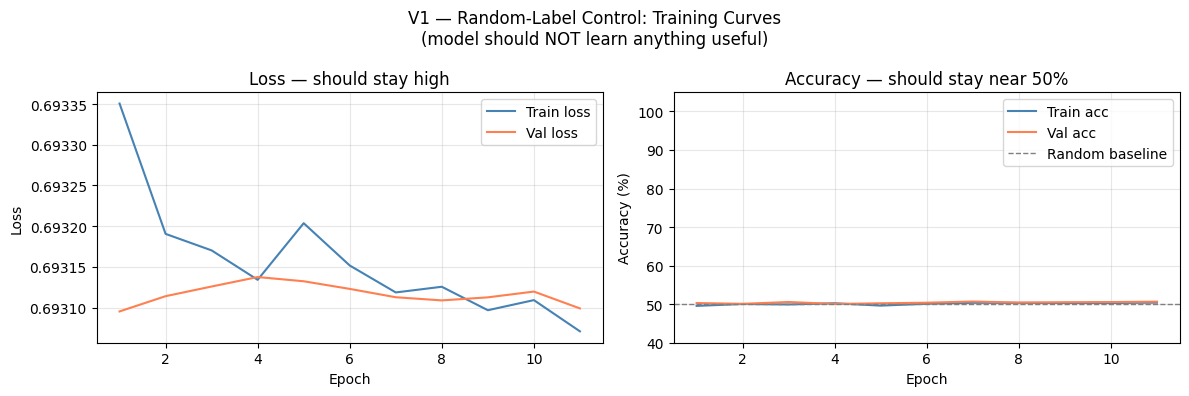

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/verification/V1_random_label_curves.png


In [4]:
# V1 — Training curve plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('V1 — Random-Label Control: Training Curves\n'
             '(model should NOT learn anything useful)', fontsize=12)

epochs_v1 = range(1, len(hist_v1.history['loss']) + 1)

ax1.plot(epochs_v1, hist_v1.history['loss'],     color='steelblue', label='Train loss')
ax1.plot(epochs_v1, hist_v1.history['val_loss'], color='coral',     label='Val loss')
ax1.set_title('Loss — should stay high')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_v1, [a*100 for a in hist_v1.history['accuracy']],
         color='steelblue', label='Train acc')
ax2.plot(epochs_v1, [a*100 for a in hist_v1.history['val_accuracy']],
         color='coral',     label='Val acc')
ax2.axhline(50, linestyle='--', color='grey', linewidth=1, label='Random baseline')
ax2.set_title('Accuracy — should stay near 50%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([40, 105])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
p = os.path.join(VERIF_DIR, 'V1_random_label_curves.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

---
# V2 — Swapped-Session Test (S2 train → S1 test)

**Question:** Is the session-dependency symmetric?  
In Experiment A we showed S1→S2 = 50%. Now we flip it: train on S2, test on S1.  

**Method:**  
- Model V2a: train S2 clean, test on S2 (in-session) and on full S1 (cross-session)  
- Produces the full 2×2 cross-session matrix alongside Experiment A's S1→S2

**Expected result:** S2→S1 ≈ 50%, matching S1→S2.  
If symmetric, it proves neither session is special — the failure is structural.

**Thesis value:** The symmetry argument makes the session-dependency claim rigorous.

In [5]:
print('=' * 55)
print('  V2 — Swapped-Session Test')
print('=' * 55)

# Load S2 clean for training
X_s2, y_s2 = load_npy('S2', MODULATION, 'clean')
X_s1, y_s1 = load_npy('S1', MODULATION, 'clean')

# Split S2 into train/val/test
X_tr_v2, X_val_v2, X_te_v2, y_tr_v2, y_val_v2, y_te_v2, _ = \
    split_trainvaltest(X_s2, y_s2)

print(f'S2 train: {X_tr_v2.shape[0]:,}  val: {X_val_v2.shape[0]:,}  test: {X_te_v2.shape[0]:,}')
print(f'S1 full : {X_s1.shape[0]:,} (used only for cross-session eval)')

model_v2 = build_cnn(LR)
ckpt_v2  = os.path.join(VERIF_DIR, 'v2_s2_single_session.keras')

t0 = time.time()
model_v2.fit(
    X_tr_v2, y_tr_v2,
    validation_data=(X_val_v2, y_val_v2),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks(ckpt_v2),
    verbose=1
)
print(f'\nTraining done in {(time.time()-t0)/60:.1f} min')

print('\nResults:')
v2_insession   = quick_eval(model_v2, X_te_v2, y_te_v2, 'S2 → S2  (in-session test)')
v2_crosssession = quick_eval(model_v2, X_s1,   y_s1,   'S2 → S1  (cross-session)')

verification_results['V2_swapped_session'] = {
    'description'    : 'CNN trained on S2 clean only, tested on S2 and S1',
    'S2_to_S2'       : v2_insession,
    'S2_to_S1'       : v2_crosssession,
}

# Print the full cross-session matrix
print('\n  Cross-session accuracy matrix:')
print(f'  {"":20}  Test S1     Test S2')
print(f'  {"-"*45}')
# S1→S1 and S1→S2 come from Experiment A results
try:
    with open(os.path.join(MODEL_DIR, 'experiment_A_results.json')) as f:
        exp_a = json.load(f)
    s1_to_s1 = exp_a['snr_results']['clean']['accuracy'] * 100
except:
    s1_to_s1 = 100.0   # known from Experiment A
s1_to_s2 = 50.13       # known from Experiment A
s2_to_s2 = v2_insession['accuracy'] * 100
s2_to_s1 = v2_crosssession['accuracy'] * 100

print(f'  {"Train S1":<20}  {s1_to_s1:>6.2f}%     {s1_to_s2:>6.2f}%')
print(f'  {"Train S2":<20}  {s2_to_s1:>6.2f}%     {s2_to_s2:>6.2f}%')

verification_results['V2_swapped_session']['cross_session_matrix'] = {
    'S1_to_S1': s1_to_s1, 'S1_to_S2': s1_to_s2,
    'S2_to_S1': s2_to_s1, 'S2_to_S2': s2_to_s2
}

sym_diff = abs(s1_to_s2 - s2_to_s1)
verdict  = f'✓ Symmetric failure ({sym_diff:.1f}% difference)' \
           if sym_diff < 10 else f'⚠  Asymmetric ({sym_diff:.1f}% difference)'
print(f'\nVerdict: {verdict}')

del X_tr_v2, X_val_v2, X_te_v2, model_v2
gc.collect()

  V2 — Swapped-Session Test
S2 train: 69,999  val: 15,001  test: 15,000
S1 full : 100,000 (used only for cross-session eval)
Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6403 - loss: 0.6730 - val_accuracy: 0.7989 - val_loss: 0.6182 - learning_rate: 1.0000e-04
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7899 - loss: 0.5750 - val_accuracy: 0.7989 - val_loss: 0.5354 - learning_rate: 1.0000e-04
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7941 - loss: 0.5116 - val_accuracy: 0.7990 - val_loss: 0.4597 - learning_rate: 1.0000e-04
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8416 - loss: 0.4012 - val_accuracy: 0.8945 - val_loss: 0.3038 - learning_rate: 1.0000e-04
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9491 - loss: 0.2348 - val_accuracy: 0.9945 - val_loss: 0.1322 - learning_rate: 1.0000e-04
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9885 - loss: 0.1106 - 

8258

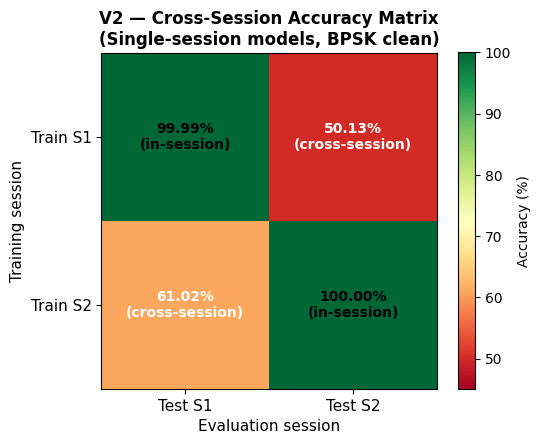

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/verification/V2_cross_session_matrix.png


6

In [6]:
# V2 — Cross-session matrix heatmap
import matplotlib.colors as mcolors

matrix = np.array([[s1_to_s1, s1_to_s2],
                   [s2_to_s1, s2_to_s2]])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=45, vmax=100)
plt.colorbar(im, ax=ax, label='Accuracy (%)')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Test S1', 'Test S2'], fontsize=11)
ax.set_yticklabels(['Train S1', 'Train S2'], fontsize=11)
ax.set_xlabel('Evaluation session', fontsize=11)
ax.set_ylabel('Training session', fontsize=11)
ax.set_title('V2 — Cross-Session Accuracy Matrix\n'
             '(Single-session models, BPSK clean)', fontweight='bold')

for i in range(2):
    for j in range(2):
        color = 'white' if matrix[i,j] < 75 else 'black'
        diag  = '(in-session)' if i == j else '(cross-session)'
        ax.text(j, i, f'{matrix[i,j]:.2f}%\n{diag}',
                ha='center', va='center', fontsize=10,
                fontweight='bold', color=color)

plt.tight_layout()
p = os.path.join(VERIF_DIR, 'V2_cross_session_matrix.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

del X_s1, y_s1, X_s2, y_s2
gc.collect()

---
# V3 — Leave-One-SNR-Out

**Question:** Why does including SNR 0 dB in training specifically matter?  
Is it enough to train on clean + SNR 20 only, or must SNR 0 be explicitly seen?

**Three training configurations:**

| Config | Training data | Hypothesis |
|---|---|---|
| V3a | S1+S2 clean only | baseline — known to fail at SNR 0 |
| V3b | S1+S2 clean + SNR20 only | partial augmentation |
| V3c | S1+S2 clean + SNR10 + SNR0 | full augmentation (Experiment A final) |

All three evaluated on the **same full S2 test set** at all SNR levels.  
V3a result should match Experiment A Model 2. V3c should match the final augmented model.

**Thesis value:** Justifies the specific augmentation recipe used — it is not arbitrary.

In [7]:
print('=' * 55)
print('  V3 — Leave-One-SNR-Out')
print('=' * 55)

def build_augmented_dataset(sessions, snr_tags):
    """Load and concatenate data from given sessions and SNR levels."""
    parts_X, parts_y = [], []
    for sess in sessions:
        for tag in snr_tags:
            Xt, yt = load_npy(sess, MODULATION, tag)
            parts_X.append(Xt)
            parts_y.append(yt)
            print(f'    Loaded {sess}/{tag}: {Xt.shape[0]:,}')
    X = np.concatenate(parts_X)
    y = np.concatenate(parts_y)
    del parts_X, parts_y
    gc.collect()
    return X, y


configs = [
    ('V3a', ['clean'],                     'S1+S2 clean only'),
    ('V3b', ['clean', 'SNR20'],            'S1+S2 clean + SNR20'),
    ('V3c', ['clean', 'SNR10', 'SNR0'],    'S1+S2 clean + SNR10 + SNR0  (final recipe)'),
]

# S2 full evaluation sets — load once, reuse for all configs
eval_snrs = [None, 20, 10, 0]
print('Loading S2 evaluation sets...')
s2_eval = {}
for snr in eval_snrs:
    tag = 'clean' if snr is None else f'SNR{snr}'
    s2_eval[snr] = load_npy('S2', MODULATION, tag)
print('S2 eval sets loaded.\n')

v3_results = {}

for cfg_name, snr_tags, description in configs:
    print(f'\n── {cfg_name}: {description} ──')

    X_pool, y_pool = build_augmented_dataset(['S1', 'S2'], snr_tags)
    X_tr, X_val, X_te, y_tr, y_val, y_te, _ = split_trainvaltest(X_pool, y_pool)
    del X_pool, y_pool
    gc.collect()

    print(f'  Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_te.shape[0]:,}')

    model_v3 = build_cnn(LR)
    ckpt_v3  = os.path.join(VERIF_DIR, f'{cfg_name}_model.keras')

    t0 = time.time()
    model_v3.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        callbacks=get_callbacks(ckpt_v3),
        verbose=1
    )
    elapsed = (time.time() - t0) / 60
    del X_tr, X_val, X_te, y_tr, y_val, y_te
    gc.collect()

    print(f'  Training done in {elapsed:.1f} min. Evaluating on full S2...')

    snr_eval_results = {}
    for snr in eval_snrs:
        Xs2, ys2 = s2_eval[snr]
        label_snr = 'clean' if snr is None else f'SNR{snr}'
        r = quick_eval(model_v3, Xs2, ys2, f'{cfg_name} → S2 {label_snr}')
        snr_eval_results[label_snr] = r

    v3_results[cfg_name] = {
        'description'  : description,
        'training_snrs': snr_tags,
        'snr_eval'     : snr_eval_results,
    }

    del model_v3
    gc.collect()

verification_results['V3_leave_one_SNR_out'] = v3_results

# Clean up eval sets
del s2_eval
gc.collect()

print('\nAll V3 configs complete.')

  V3 — Leave-One-SNR-Out
Loading S2 evaluation sets...
S2 eval sets loaded.


── V3a: S1+S2 clean only ──
    Loaded S1/clean: 100,000
    Loaded S2/clean: 100,000
  Train: 139,999  Val: 30,001  Test: 30,000
Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7090 - loss: 0.6110 - val_accuracy: 0.8430 - val_loss: 0.4993 - learning_rate: 1.0000e-04
Epoch 2/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8396 - loss: 0.4487 - val_accuracy: 0.8477 - val_loss: 0.3776 - learning_rate: 1.0000e-04
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8605 - loss: 0.3294 - val_accuracy: 0.8945 - val_loss: 0.2471 - learning_rate: 1.0000e-04
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9152 - loss: 0.2210 - val_accuracy: 0.9495 - val_loss: 0.1558 - learning_rate: 1.0000e-04
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9388 - loss: 0.1576 - val_accuracy: 0.9611 - val_loss: 0.1138 - learning_rate: 1.0000e-04
Epoch


  Config                              Clean    SNR20    SNR10     SNR0
  --------------------------------------------------------------------
  S1+S2 clean only                 100.00%  100.00%   99.70%   58.58%
  S1+S2 clean + SNR20              100.00%  100.00%   99.67%   55.16%
  S1+S2 clean + SNR10 + SNR0  (final recipe) 100.00%  100.00%  100.00%   99.97%


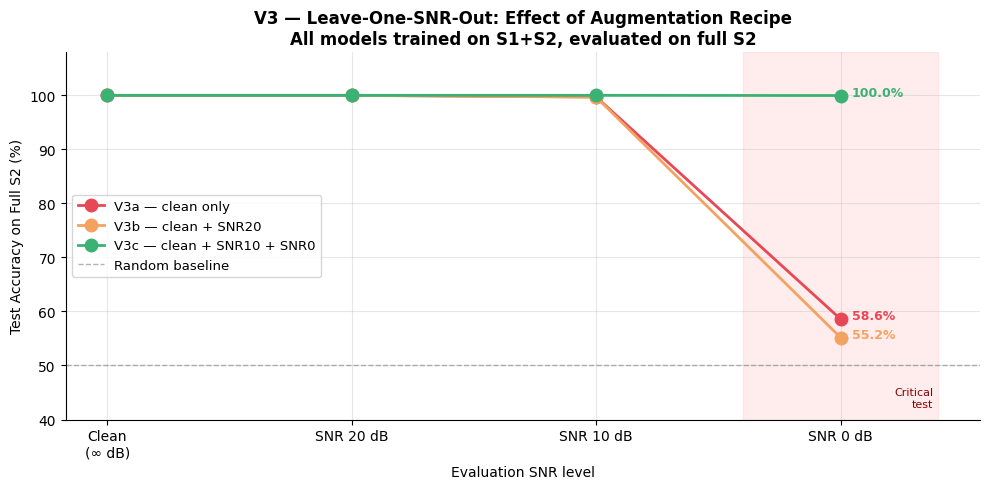

Saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/verification/V3_leave_one_SNR_out.png


In [8]:
# V3 — Summary table and plot
snr_cols   = ['clean', 'SNR20', 'SNR10', 'SNR0']
snr_labels = ['Clean\n(∞ dB)', 'SNR 20 dB', 'SNR 10 dB', 'SNR 0 dB']
cfg_colors = {'V3a': '#E84855', 'V3b': '#F4A261', 'V3c': '#3BB273'}
cfg_labels = {
    'V3a': 'V3a — clean only',
    'V3b': 'V3b — clean + SNR20',
    'V3c': 'V3c — clean + SNR10 + SNR0'
}

# Print summary table
print(f'\n  {"Config":<32} {"Clean":>8} {"SNR20":>8} {"SNR10":>8} {"SNR0":>8}')
print('  ' + '-' * 68)
for cfg_name, res in v3_results.items():
    row = [res['snr_eval'].get(c, {}).get('accuracy', 0) * 100 for c in snr_cols]
    print(f'  {res["description"]:<32} ' +
          '  '.join(f'{v:>6.2f}%' for v in row))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

xs = range(4)
for cfg_name, res in v3_results.items():
    accs = [res['snr_eval'].get(c, {}).get('accuracy', 0) * 100 for c in snr_cols]
    ax.plot(xs, accs, marker='o', color=cfg_colors[cfg_name],
            linewidth=2, markersize=9, label=cfg_labels[cfg_name])
    # Annotate SNR 0 point specifically
    ax.annotate(f'{accs[-1]:.1f}%', (3, accs[-1]),
                textcoords='offset points', xytext=(8, 0),
                fontsize=9, color=cfg_colors[cfg_name], fontweight='bold')

ax.axhline(50, linestyle='--', color='grey', linewidth=1, alpha=0.6,
           label='Random baseline')
ax.set_xticks(xs)
ax.set_xticklabels(snr_labels)
ax.set_ylabel('Test Accuracy on Full S2 (%)')
ax.set_xlabel('Evaluation SNR level')
ax.set_title('V3 — Leave-One-SNR-Out: Effect of Augmentation Recipe\n'
             'All models trained on S1+S2, evaluated on full S2',
             fontweight='bold')
ax.set_ylim([40, 108])
ax.legend(fontsize=9.5)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Shade SNR 0 column to highlight the critical test
ax.axvspan(2.6, 3.4, alpha=0.07, color='red')
ax.text(3.38, 42, 'Critical\ntest', fontsize=8, color='darkred',
        ha='right', va='bottom')

plt.tight_layout()
p = os.path.join(VERIF_DIR, 'V3_leave_one_SNR_out.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

---
# Section 10 — Save All Results + Final Summary

In [9]:
json_path = os.path.join(MODEL_DIR, 'verification_results.json')
with open(json_path, 'w') as f:
    json.dump(verification_results, f, indent=2)

print(f'Results saved: {json_path}')
print()
print('═' * 60)
print('  VERIFICATION SUITE SUMMARY')
print('═' * 60)

# V1
v1 = verification_results['V1_random_label']
v1_verdict = '✓ PASS' if v1['test_accuracy'] < 0.60 else '✗ FAIL'
print(f'\nV1 — Random-Label Control')
print(f'  Test accuracy : {v1["test_accuracy"]*100:.2f}%  '
      f'(expected ~50%)  {v1_verdict}')
print(f'  Test AUC      : {v1["test_auc"]:.4f}  (expected ~0.5)')

# V2
v2 = verification_results['V2_swapped_session']['cross_session_matrix']
print(f'\nV2 — Cross-Session Matrix')
print(f'  S1→S1: {v2["S1_to_S1"]:.2f}%   S1→S2: {v2["S1_to_S2"]:.2f}%')
print(f'  S2→S1: {v2["S2_to_S1"]:.2f}%   S2→S2: {v2["S2_to_S2"]:.2f}%')
sym = abs(v2['S1_to_S2'] - v2['S2_to_S1'])
print(f'  Symmetry delta: {sym:.2f}%  '
      + ('✓ symmetric' if sym < 10 else '⚠  asymmetric'))

# V3
print(f'\nV3 — Leave-One-SNR-Out  (accuracy on full S2 at SNR 0 dB)')
for cfg_name, res in verification_results['V3_leave_one_SNR_out'].items():
    acc0 = res['snr_eval'].get('SNR0', {}).get('accuracy', 0) * 100
    print(f'  {cfg_name} ({res["description"]:<35}) → SNR0: {acc0:.2f}%')

print('═' * 60)
print(f'\nAll verification plots saved to: {VERIF_DIR}')

Results saved: /content/drive/MyDrive/My Thesis/Models/ExperimentA/verification_results.json

════════════════════════════════════════════════════════════
  VERIFICATION SUITE SUMMARY
════════════════════════════════════════════════════════════

V1 — Random-Label Control
  Test accuracy : 50.45%  (expected ~50%)  ✓ PASS
  Test AUC      : 0.5065  (expected ~0.5)

V2 — Cross-Session Matrix
  S1→S1: 99.99%   S1→S2: 50.13%
  S2→S1: 61.02%   S2→S2: 100.00%
  Symmetry delta: 10.89%  ⚠  asymmetric

V3 — Leave-One-SNR-Out  (accuracy on full S2 at SNR 0 dB)
  V3a (S1+S2 clean only                   ) → SNR0: 58.58%
  V3b (S1+S2 clean + SNR20                ) → SNR0: 55.16%
  V3c (S1+S2 clean + SNR10 + SNR0  (final recipe)) → SNR0: 99.97%
════════════════════════════════════════════════════════════

All verification plots saved to: /content/drive/MyDrive/My Thesis/Models/ExperimentA/verification
